 #### Google Drive Connect

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive connected!")

Mounted at /content/drive
✅ Drive connected!


In [ ]:
# import os

# print(os.path.exists("/content/drive/MyDrive/street_food_dataset.zip"))
# import os

# for root, dirs, files in os.walk("/content/drive/MyDrive"):
#     for file in files:
#         if file == "street_food_dataset.zip":
#             print(os.path.join(root, file))

#### Dataset Extract

In [ ]:
import zipfile, os

# Drive থেকে zip খুলে /content/raw_dataset এ রাখো
with zipfile.ZipFile("/content/drive/MyDrive/street_food_dataset.zip", 'r') as z:
    z.extractall("/content/raw_dataset")

# ভেতরে কী আছে দেখো
print("✅ Extract সম্পন্ন! ভেতরে আছে:")
for item in os.listdir("/content/raw_dataset"):
    print(f"  {item}")

✅ Extract সম্পন্ন! ভেতরে আছে:
  street_food_dataset


 #### Folder Flatten

In [ ]:
import shutil

# nested folder → flat folder
source = "/content/raw_dataset/street_food_dataset"
flat   = "/content/flat_dataset"
os.makedirs(flat, exist_ok=True)

for food_type in os.listdir(source):
    food_path = os.path.join(source, food_type)
    if not os.path.isdir(food_path):
        continue
    for quality in os.listdir(food_path):
        quality_path = os.path.join(food_path, quality)
        if not os.path.isdir(quality_path):
            continue
        # নতুন folder নাম: "beguni_fresh", "singara_poor" ইত্যাদি
        new_class = f"{food_type}_{quality}".lower()
        new_path  = os.path.join(flat, new_class)
        os.makedirs(new_path, exist_ok=True)
        for img in os.listdir(quality_path):
            shutil.copy(
                os.path.join(quality_path, img),
                os.path.join(new_path, img)
            )

classes = os.listdir(flat)
total   = sum(len(os.listdir(os.path.join(flat, c))) for c in classes)
print(f"✅ Flatten সম্পন্ন! মোট class: {len(classes)}, মোট ছবি: {total}")

✅ Flatten সম্পন্ন! মোট class: 36, মোট ছবি: 2065


#### Formating Image

In [ ]:
from PIL import Image

converted = 0
for class_name in os.listdir(flat):
    class_path = os.path.join(flat, class_name)
    for fname in os.listdir(class_path):
        ext = os.path.splitext(fname)[1].lower()
        if ext in ['.jfif', '.avif', '.webp']:
            fpath    = os.path.join(class_path, fname)
            new_path = os.path.join(class_path,
                       os.path.splitext(fname)[0] + ".jpg")
            try:
                Image.open(fpath).convert("RGB").save(new_path, "JPEG")
                os.remove(fpath)
                converted += 1
            except:
                pass

print(f"✅ {converted}টা ছবি convert হয়েছে। সব এখন .jpg/.jpeg/.png!")

✅ 340টা ছবি convert হয়েছে। সব এখন .jpg/.jpeg/.png!


####  Data Augmentation

In [ ]:
from PIL import ImageEnhance, ImageFilter
import random

augmented = "/content/augmented_dataset"
os.makedirs(augmented, exist_ok=True)
TARGET = 150
random.seed(42)

def augment_image(img):
    choice = random.randint(0, 6)
    if choice == 0:
        return img.transpose(Image.FLIP_LEFT_RIGHT)       # উল্টানো
    elif choice == 1:
        return img.rotate(random.randint(-25, 25))         # ঘোরানো
    elif choice == 2:
        return ImageEnhance.Brightness(img).enhance(random.uniform(0.6, 1.4))  # উজ্জ্বলতা
    elif choice == 3:
        return ImageEnhance.Contrast(img).enhance(random.uniform(0.6, 1.4))    # contrast
    elif choice == 4:
        return ImageEnhance.Color(img).enhance(random.uniform(0.6, 1.4))       # রঙ
    elif choice == 5:
        return img.filter(ImageFilter.GaussianBlur(radius=1))                  # blur
    else:
        w, h = img.size
        l = random.randint(0, w//6)
        t = random.randint(0, h//6)
        r = w - random.randint(0, w//6)
        b = h - random.randint(0, h//6)
        return img.crop((l,t,r,b)).resize((224, 224))     # crop

for class_name in os.listdir(flat):
    class_path     = os.path.join(flat, class_name)
    new_class_path = os.path.join(augmented, class_name)
    os.makedirs(new_class_path, exist_ok=True)

    originals = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))]

    # আসল ছবিগুলো copy করো
    for img_file in originals:
        shutil.copy(os.path.join(class_path, img_file),
                    os.path.join(new_class_path, img_file))

    # দরকার হলে extra ছবি বানাও
    needed    = max(0, TARGET - len(originals))
    aug_count = 0
    while aug_count < needed:
        src = random.choice(originals)
        try:
            img     = Image.open(os.path.join(class_path, src)).convert("RGB")
            aug_img = augment_image(img)
            aug_img.save(os.path.join(new_class_path,
                         f"aug_{aug_count:04d}_{src}"), "JPEG")
            aug_count += 1
        except:
            continue

total_aug = sum(len(os.listdir(os.path.join(augmented, c)))
                for c in os.listdir(augmented))
print(f"✅ Augmentation সম্পন্ন! মোট ছবি এখন: {total_aug}")

✅ Augmentation সম্পন্ন! মোট ছবি এখন: 5400


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

###Count Images in Each Class

In [ ]:
dataset_path = "/content/flat_dataset"

classes = sorted(os.listdir(dataset_path))

image_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ])

    image_counts[cls] = count

print("Total Classes:", len(classes))
print("Total Images:", sum(image_counts.values()))

Total Classes: 36
Total Images: 2064


###Images per Class (Bar Chart)

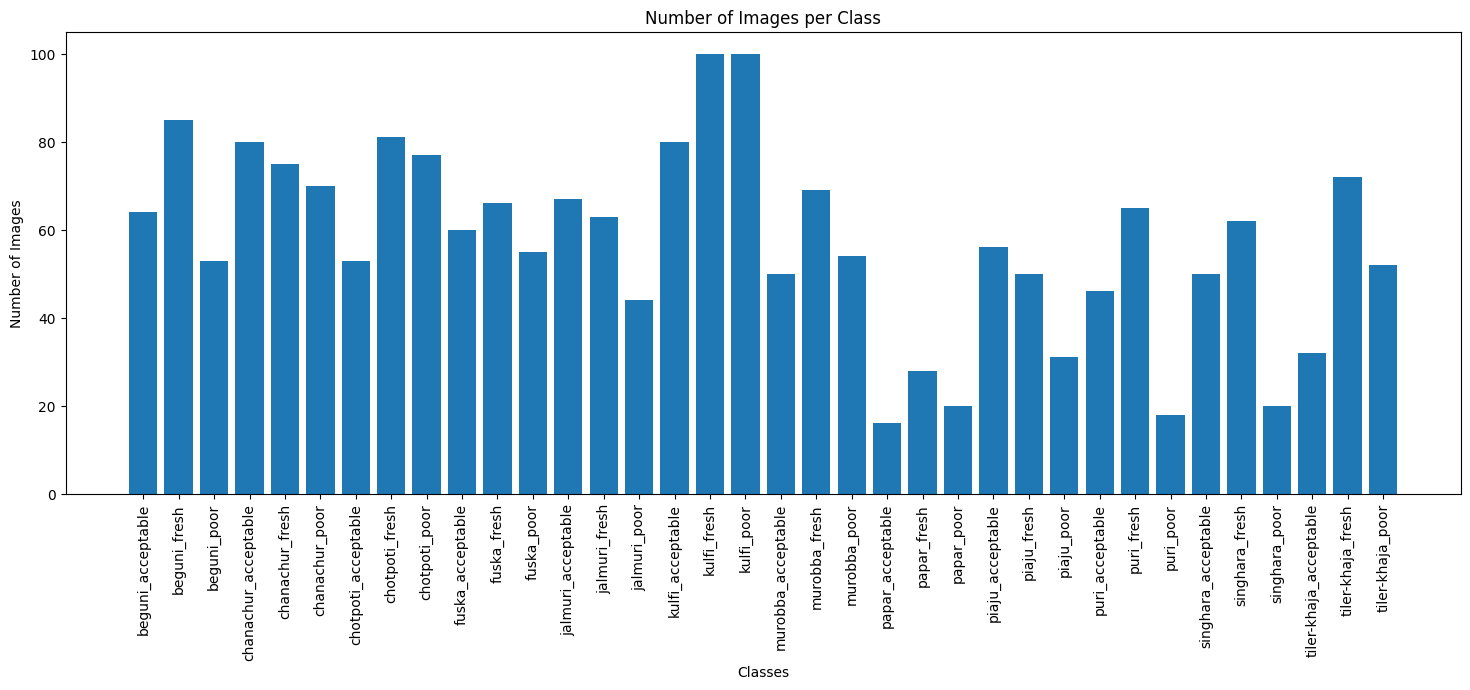

In [ ]:
plt.figure(figsize=(18,6))

plt.bar(image_counts.keys(), image_counts.values())

plt.xticks(rotation=90)

plt.xlabel("Classes")

plt.ylabel("Number of Images")

plt.title("Number of Images per Class")

plt.show()

###Class Distribution Pie Chart

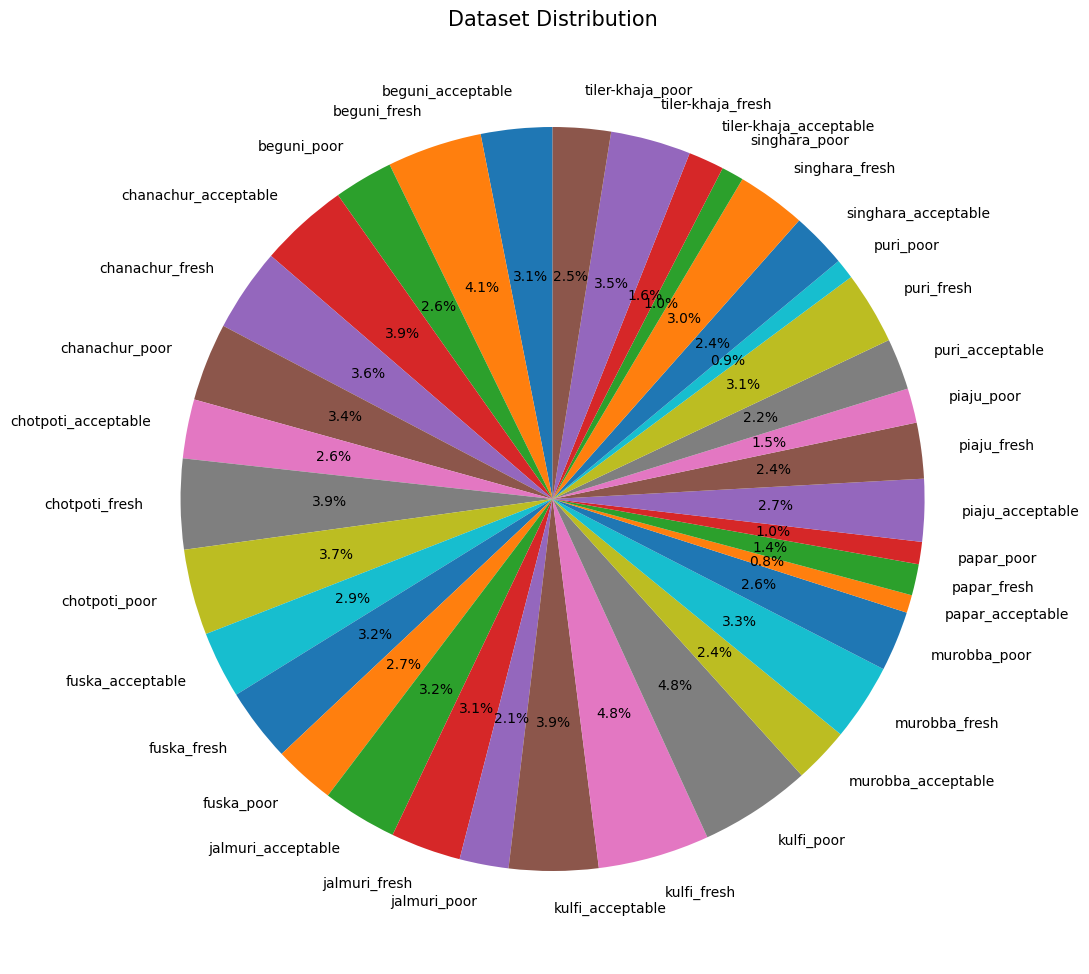

In [ ]:
plt.figure(figsize=(12, 18))

plt.pie(
    image_counts.values(),
    labels=image_counts.keys(),
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Dataset Distribution", fontsize=15)

plt.show()

####Show Random Images from Dataset

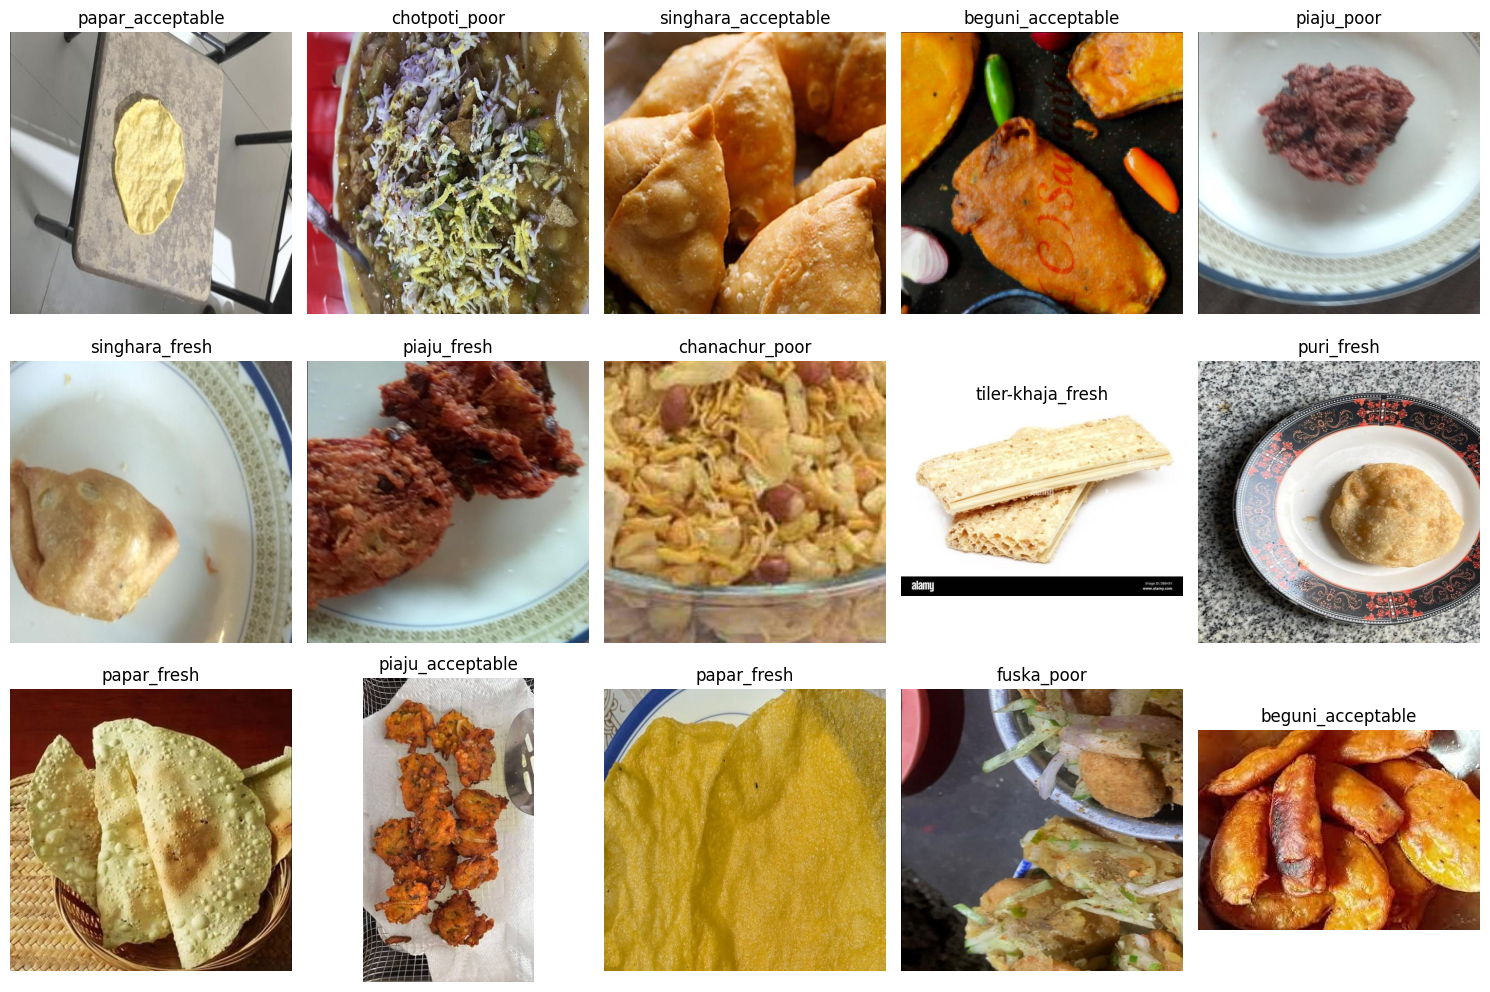

In [ ]:
fig, axes = plt.subplots(3,5, figsize=(15,10))

for ax in axes.flat:

    cls = random.choice(classes)

    img_name = random.choice(os.listdir(os.path.join(dataset_path, cls)))

    img = Image.open(os.path.join(dataset_path, cls, img_name))

    ax.imshow(img)

    ax.set_title(cls)

    ax.axis("off")

plt.tight_layout()

plt.show()

####Image Size Analysis

In [ ]:
widths = []
heights = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img = Image.open(os.path.join(class_path, img_name))

        widths.append(img.size[0])

        heights.append(img.size[1])

print("Average Width :", np.mean(widths))
print("Average Height:", np.mean(heights))

print("Minimum Width :", np.min(widths))
print("Maximum Width :", np.max(widths))

print("Minimum Height:", np.min(heights))
print("Maximum Height:", np.max(heights))

Average Width : 563.8638565891473
Average Height: 544.6414728682171
Minimum Width : 146
Maximum Width : 3240
Minimum Height: 104
Maximum Height: 2160


###Histogram of Image Width

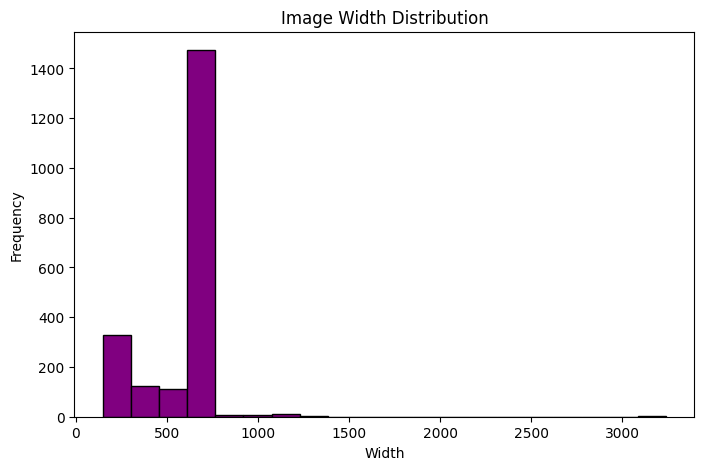

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(widths, bins=20, color='purple',
    edgecolor='black')

plt.title("Image Width Distribution")

plt.xlabel("Width")

plt.ylabel("Frequency")

plt.show()

###Histogram of Image Height

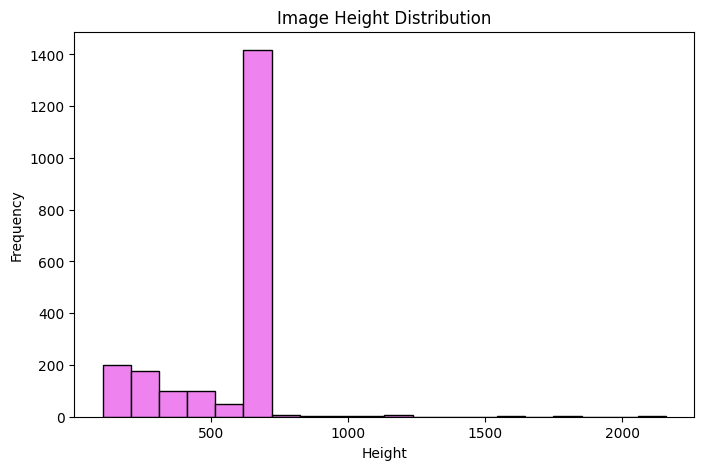

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(heights, bins=20, color='violet',
    edgecolor='black')

plt.title("Image Height Distribution")

plt.xlabel("Height")

plt.ylabel("Frequency")

plt.show()

###RGB Channel Distribution

In [ ]:
import os
import random
import numpy as np
from PIL import Image

dataset_path = "/content/flat_dataset"
classes = sorted(os.listdir(dataset_path))

r, g, b = [], [], []

random.seed(42)

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith((".jpg",".jpeg",".png"))]

    for img_name in random.sample(images, min(5, len(images))):

        img = np.array(Image.open(os.path.join(class_path, img_name)).convert("RGB"))

        pixels = img.reshape(-1,3)

        # Sample only 1000 pixels
        idx = np.random.choice(len(pixels), min(1000, len(pixels)), replace=False)

        sample = pixels[idx]

        r.extend(sample[:,0])
        g.extend(sample[:,1])
        b.extend(sample[:,2])

###Aspect Ratio Analysis

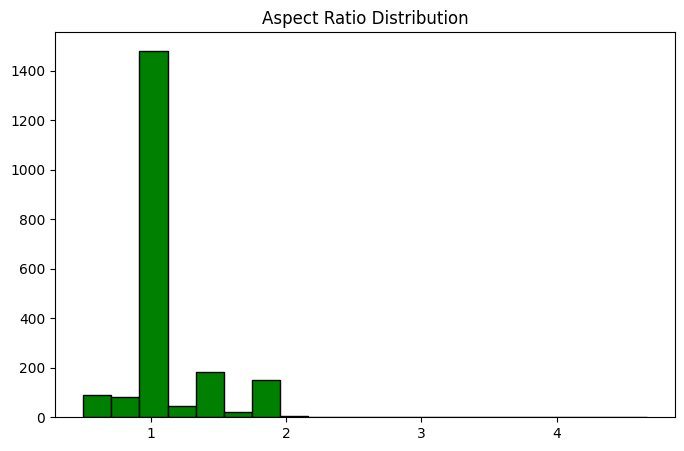

In [ ]:
ratios = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img = Image.open(os.path.join(class_path, img_name))

        ratios.append(img.width/img.height)

plt.figure(figsize=(8,5))
plt.hist(ratios, bins=20, color='green',
    edgecolor='black')
plt.title("Aspect Ratio Distribution")
plt.show()

###Check Corrupted Images

In [ ]:
bad_images = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        try:
            Image.open(os.path.join(class_path, img_name)).verify()

        except:
            bad_images.append(os.path.join(cls, img_name))

print("Corrupted Images:", len(bad_images))

bad_images[:10]

Corrupted Images: 0


[]

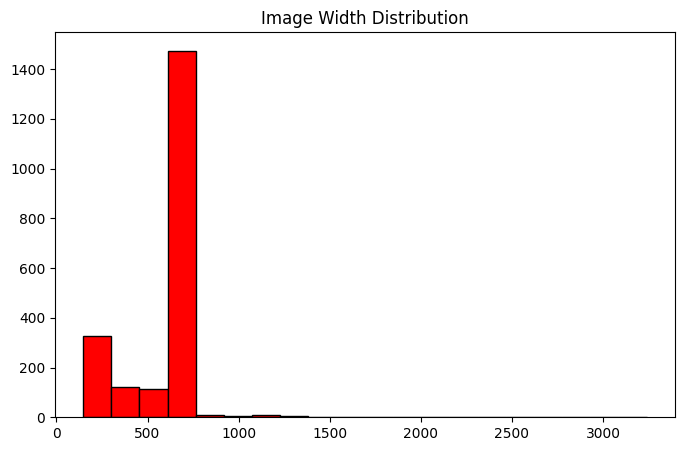

In [ ]:
widths = []
heights = []

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):
        img = Image.open(os.path.join(class_path, img_name))
        widths.append(img.width)
        heights.append(img.height)

plt.figure(figsize=(8,5))
plt.hist(widths, bins=20, color='red',
    edgecolor='black')
plt.title("Image Width Distribution")
plt.show()

###Brightness Distribution

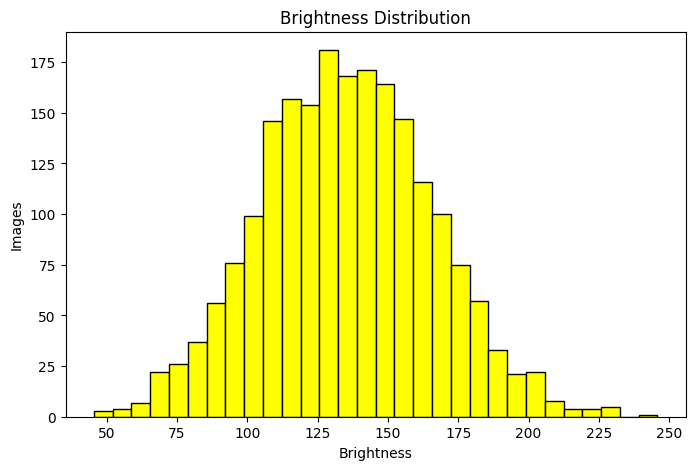

In [ ]:
brightness = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img = Image.open(
            os.path.join(class_path, img_name)
        ).convert("L")

        brightness.append(np.array(img).mean())
plt.figure(figsize=(8,5))
plt.hist(brightness, bins=30, color='yellow',
    edgecolor='black')

plt.xlabel("Brightness")
plt.ylabel("Images")
plt.title("Brightness Distribution")
plt.show()

###Blur / Sharpness Analysis

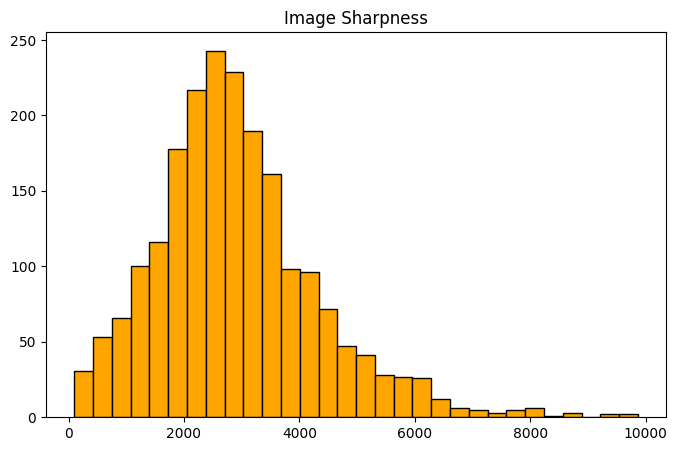

In [ ]:
from PIL import ImageFilter

sharpness = []

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img = Image.open(
            os.path.join(class_path,img_name)
        ).convert("L")

        img = np.array(img)

        sharpness.append(img.var())
plt.figure(figsize=(8,5))
plt.hist(sharpness,bins=30,  color='orange',
    edgecolor='black')

plt.title("Image Sharpness")
plt.show()

###Duplicate Images

In [ ]:
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 14.7 MB/s eta 0:00:00


In [ ]:
import imagehash

hashes = {}

duplicates = []

for cls in classes:

    class_path = os.path.join(dataset_path,cls)

    for img_name in os.listdir(class_path):

        path = os.path.join(class_path,img_name)

        h = imagehash.average_hash(Image.open(path))

        if h in hashes:

            duplicates.append(path)

        else:

            hashes[h]=path

print("Duplicates:",len(duplicates))

for cls in classes:

    count = len(os.listdir(os.path.join(dataset_path,cls)))

    if count==0:

        print(cls)

Duplicates: 122


###Dataset Summary Table

In [ ]:
import os

dataset_path = "/content/flat_dataset"

classes = sorted(os.listdir(dataset_path))

image_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    image_counts[cls] = count

print("Total Classes:", len(classes))
print("Total Images:", sum(image_counts.values()))

Total Classes: 36
Total Images: 2064


In [ ]:
import pandas as pd

summary = pd.DataFrame({
    "Class": list(image_counts.keys()),
    "Images": list(image_counts.values())
})

summary.loc[len(summary)] = [
    "TOTAL",
    summary["Images"].sum()
]

summary

,Class,Images
0,beguni_acceptable,64
1,beguni_fresh,85
2,beguni_poor,53
3,chanachur_acceptable,80
4,chanachur_fresh,75
5,chanachur_poor,70
6,chotpoti_acceptable,53
7,chotpoti_fresh,81
8,chotpoti_poor,77
9,fuska_acceptable,60


#### Train/Valid/Test Split

In [ ]:
output = "/content/aug_split"
random.seed(42)

for class_name in os.listdir(augmented):
    class_path = os.path.join(augmented, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)

    n       = len(images)
    n_train = int(n * 0.70)  # ৭০% train
    n_valid = int(n * 0.15)  # ১৫% valid

    splits = {
        "train": images[:n_train],
        "valid": images[n_train:n_train+n_valid],
        "test":  images[n_train+n_valid:]          # বাকি ১৫% test
    }

    for split, imgs in splits.items():
        split_dir = os.path.join(output, split, class_name)
        os.makedirs(split_dir, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(class_path, img),
                        os.path.join(split_dir, img))

print("✅ Split সম্পন্ন!")
for split in ["train", "valid", "test"]:
    total = sum(len(os.listdir(os.path.join(output, split, c)))
                for c in os.listdir(os.path.join(output, split)))
    print(f"  {split}: {total}টা ছবি")

✅ Split সম্পন্ন!
  train: 3780টা ছবি
  valid: 792টা ছবি
  test: 828টা ছবি


In [ ]:
import shutil
shutil.make_archive("/content/drive/MyDrive/aug_split_backup", 'zip', "/content/aug_split")
print("✅ Preprocessed dataset Drive-e backup hoise!")

✅ Preprocessed dataset Drive-e backup hoise!


In [ ]:
import zipfile
with zipfile.ZipFile("/content/drive/MyDrive/aug_split_backup.zip", 'r') as z:
    z.extractall("/content/aug_split")

#### Model Setup + Training

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from collections import Counter

# ✅ IMPROVEMENT 1: Seed fix — reproducibility-er jonno
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

DRIVE_MODEL_PATH = "/content/drive/MyDrive/street_food_best_model.pth"

# Transform — train-এ augmentation, valid/test-এ সাধারণ resize
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset load
train_data = datasets.ImageFolder("/content/aug_split/train", transform=train_transform)
valid_data = datasets.ImageFolder("/content/aug_split/valid", transform=val_test_transform)
test_data  = datasets.ImageFolder("/content/aug_split/test",  transform=val_test_transform)
num_classes = len(train_data.classes)
print(f"Train: {len(train_data)} | Valid: {len(valid_data)} | Test: {len(test_data)}")
print(f"মোট class: {num_classes}")

with open("/content/drive/MyDrive/class_names.txt", "w") as f:
    f.write("\n".join(train_data.classes))
print("✅ class_names.txt Drive-এ save হয়েছে")

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

class_counts = Counter(train_data.targets)
total        = len(train_data)
weights      = [total/(num_classes*class_counts[i]) for i in range(num_classes)]
weights      = torch.tensor(weights, dtype=torch.float).to(device)
criterion    = nn.CrossEntropyLoss(weight=weights)

# EfficientNet model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.classifier[1] = nn.Linear(1280, num_classes)
for param in model.classifier.parameters():
    param.requires_grad = True
model = model.to(device)

# ── Phase 1: শুধু Classifier train (20 epoch) ──
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.0001)
# ✅ IMPROVEMENT 3: LR Scheduler (Phase 1)
scheduler1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
best_val_acc = 0

print("\nPhase 1 শুরু (Frozen Backbone)...")
for epoch in range(20):
    model.train()
    train_correct = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_data) * 100
    val_acc   = val_correct   / len(valid_data) * 100
    scheduler1.step(val_acc)   # ✅ scheduler update

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), DRIVE_MODEL_PATH)
        print(f"Epoch [{epoch+1:2d}/20] Train: {train_acc:.1f}% | Val: {val_acc:.1f}% ← ✅ Best! (Drive-এ saved)")
    else:
        print(f"Epoch [{epoch+1:2d}/20] Train: {train_acc:.1f}% | Val: {val_acc:.1f}%")

print(f"\nPhase 1 শেষ! Best Val: {best_val_acc:.2f}%")

# ── Phase 2: Fine-tuning ──
model.load_state_dict(torch.load(DRIVE_MODEL_PATH))

# ✅ IMPROVEMENT 2: beshi block unfreeze (features[6:] → features[4:])
for param in model.features[4:].parameters():
    param.requires_grad = True

optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=0.00001
)
# ✅ IMPROVEMENT 3: LR Scheduler (Phase 2)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer2, mode='max', factor=0.5, patience=3)

print("\nPhase 2 শুরু (Fine-tuning)...")
for epoch in range(15):
    model.train()
    train_correct = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer2.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_data) * 100
    val_acc   = val_correct   / len(valid_data) * 100
    scheduler2.step(val_acc)   # ✅ scheduler update

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), DRIVE_MODEL_PATH)
        print(f"FT [{epoch+1:2d}/15] Train: {train_acc:.1f}% | Val: {val_acc:.1f}% ← ✅ Best! (Drive-এ saved)")
    else:
        print(f"FT [{epoch+1:2d}/15] Train: {train_acc:.1f}% | Val: {val_acc:.1f}%")

print(f"\n✅ Training সম্পন্ন! Best Val Accuracy: {best_val_acc:.2f}%")
print(f"📁 Final model Drive-এ ache: {DRIVE_MODEL_PATH}")

Device: cuda
Train: 3780 | Valid: 792 | Test: 828
মোট class: 36
✅ class_names.txt Drive-এ save হয়েছে

Phase 1 শুরু (Frozen Backbone)...
Epoch [ 1/20] Train: 10.6% | Val: 23.4% ← ✅ Best! (Drive-এ saved)
Epoch [ 2/20] Train: 27.8% | Val: 38.4% ← ✅ Best! (Drive-এ saved)
Epoch [ 3/20] Train: 39.8% | Val: 44.1% ← ✅ Best! (Drive-এ saved)
Epoch [ 4/20] Train: 46.2% | Val: 48.5% ← ✅ Best! (Drive-এ saved)
Epoch [ 5/20] Train: 50.9% | Val: 52.4% ← ✅ Best! (Drive-এ saved)
Epoch [ 6/20] Train: 53.2% | Val: 53.5% ← ✅ Best! (Drive-এ saved)
Epoch [ 7/20] Train: 56.1% | Val: 54.9% ← ✅ Best! (Drive-এ saved)
Epoch [ 8/20] Train: 56.6% | Val: 56.9% ← ✅ Best! (Drive-এ saved)
Epoch [ 9/20] Train: 58.1% | Val: 57.6% ← ✅ Best! (Drive-এ saved)
Epoch [10/20] Train: 59.6% | Val: 58.5% ← ✅ Best! (Drive-এ saved)
Epoch [11/20] Train: 60.0% | Val: 57.7%
Epoch [12/20] Train: 60.8% | Val: 60.7% ← ✅ Best! (Drive-এ saved)
Epoch [13/20] Train: 61.2% | Val: 59.5%
Epoch [14/20] Train: 63.0% | Val: 61.0% ← ✅ Best! (Drive-

####  Test Accuracy

In [ ]:
from sklearn.metrics import classification_report

model.load_state_dict(torch.load("/content/drive/MyDrive/street_food_best_model.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

correct  = sum(p == l for p, l in zip(all_preds, all_labels))
test_acc = correct / len(all_labels) * 100
print(f"✅ Test Accuracy: {test_acc:.2f}%")
print("\nPer-class Report:")
print(classification_report(all_labels, all_preds,
      target_names=train_data.classes, digits=2))

✅ Test Accuracy: 76.57%

Per-class Report:
                        precision    recall  f1-score   support

     beguni_acceptable       0.65      0.57      0.60        23
          beguni_fresh       0.68      0.83      0.75        23
           beguni_poor       0.84      0.70      0.76        23
  chanachur_acceptable       0.60      0.52      0.56        23
       chanachur_fresh       0.60      0.91      0.72        23
        chanachur_poor       0.92      0.52      0.67        23
   chotpoti_acceptable       0.90      0.78      0.84        23
        chotpoti_fresh       0.81      0.96      0.88        23
         chotpoti_poor       0.95      0.91      0.93        23
      fuska_acceptable       0.76      0.70      0.73        23
           fuska_fresh       0.73      0.83      0.78        23
            fuska_poor       0.88      0.91      0.89        23
    jalmuri_acceptable       0.50      0.39      0.44        23
         jalmuri_fresh       0.59      0.70      0.64       

#Accuracy Analysis

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 34.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=66a2ac7af4a8ebf0ba682a51a0f62b058e05d8633cfd90ca9140cec1b3f66f07
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


###analyze_food_quality + display_result

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt


target_layer = [model.features[-1]]

def analyze_food_quality(image_path, model=model, target_layer=target_layer, class_names=class_names):
    img = Image.open(image_path).convert("RGB")
    img_resized = img.resize((224, 224))
    rgb_img = np.array(img_resized) / 255.0
    input_tensor = val_test_transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        pred_class = class_names[pred_idx]
        confidence = probs[pred_idx].item() * 100

    cam = GradCAM(model=model, target_layers=target_layer)
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    heatmap = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    food_type, quality = pred_class.rsplit("_", 1)
    food_type_display = food_type.replace("-", " ").title()
    explanations = {
        "fresh": f"This {food_type_display} appears fresh and well-prepared. The color and texture look normal, and it seems safe to eat.",
        "acceptable": f"This {food_type_display} is edible but shows minor signs of aging or imperfection. Consider it with some caution.",
        "poor": f"This {food_type_display} shows signs of being overcooked, stale, burnt, or of poor quality. Exercise caution before eating."
    }
    explanation = explanations.get(quality, "Quality could not be determined.") + f" (Model confidence: {confidence:.1f}%)"

    return {
        "original_image": img_resized, "heatmap": heatmap,
        "food_type": food_type_display, "quality": quality,
        "predicted_class": pred_class, "confidence": confidence,
        "explanation": explanation, "all_probs": probs.cpu().numpy()
    }

def display_result(image_path):
    result = analyze_food_quality(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(result["original_image"]); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(result["heatmap"]); axes[1].set_title(f"{result['predicted_class']} ({result['confidence']:.1f}%)"); axes[1].axis("off")
    plt.tight_layout(); plt.show()
    print(f"Food Type: {result['food_type']}")
    print(f"Quality: {result['quality'].title()}")
    print(f"Confidence: {result['confidence']:.2f}%")
    print(f"\nExplanation: {result['explanation']}")

### Display

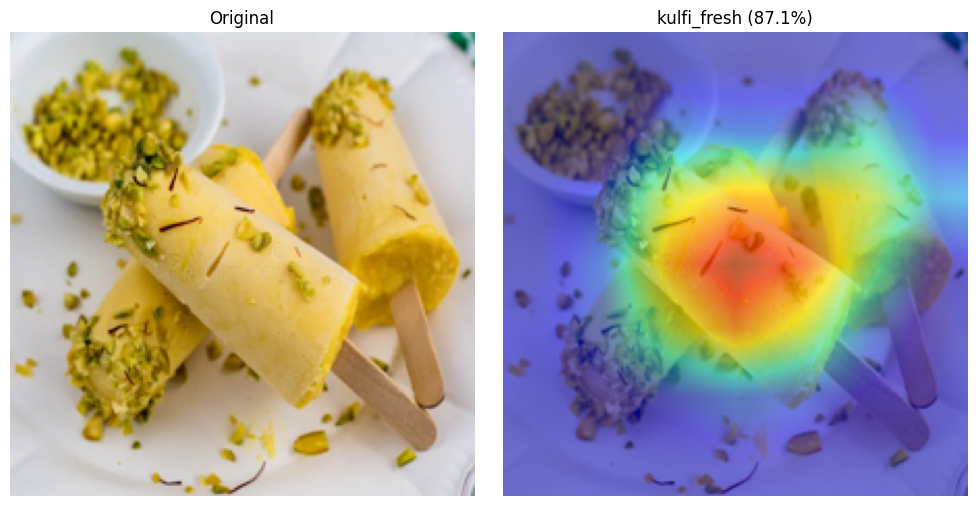

Food Type: Kulfi
Quality: Fresh
Confidence: 87.11%

Explanation: This Kulfi appears fresh and well-prepared. The color and texture look normal, and it seems safe to eat. (Model confidence: 87.1%)


In [ ]:
test_image_path = "/content/flat_dataset/kulfi_fresh/" + os.listdir("/content/flat_dataset/kulfi_fresh")[0]
display_result(test_image_path)

In [ ]:
import shutil
demo_dir = "/content/drive/MyDrive/demo_samples"
os.makedirs(demo_dir, exist_ok=True)

for cls in class_names[:5]:  # kichu example class theke
    class_path = os.path.join("/content/flat_dataset", cls)
    originals = [f for f in os.listdir(class_path) if not f.startswith("aug_")]
    shutil.copy(os.path.join(class_path, originals[0]), os.path.join(demo_dir, f"{cls}.jpg"))

print("✅ Demo samples saved to Drive")

✅ Demo samples saved to Drive


#Just for test!!!!!::

## 🚀 Quick Load — Run These Cells Only (No Retraining Needed)
Notebook-er shuru theke run korার dorkar nai। Model already trained, Drive-e save ache।
Just niche-r cell gula order onujayi run koro.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile, os, shutil

with zipfile.ZipFile("/content/drive/MyDrive/aug_split_backup.zip", 'r') as z:
    z.extractall("/content/aug_split")

with zipfile.ZipFile("/content/drive/MyDrive/street_food_dataset.zip", 'r') as z:
    z.extractall("/content/raw_dataset")

source = "/content/raw_dataset/street_food_dataset"
flat   = "/content/flat_dataset"
os.makedirs(flat, exist_ok=True)

for food_type in os.listdir(source):
    food_path = os.path.join(source, food_type)
    if not os.path.isdir(food_path):
        continue
    for quality in os.listdir(food_path):
        quality_path = os.path.join(food_path, quality)
        if not os.path.isdir(quality_path):
            continue
        new_class = f"{food_type}_{quality}".lower()
        new_path  = os.path.join(flat, new_class)
        os.makedirs(new_path, exist_ok=True)
        for img in os.listdir(quality_path):
            shutil.copy(os.path.join(quality_path, img), os.path.join(new_path, img))

print("✅ Dataset ready")

✅ Dataset ready


In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

with open("/content/drive/MyDrive/class_names.txt") as f:
    class_names = f.read().splitlines()
num_classes = len(class_names)

model = models.efficientnet_b0(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(torch.load("/content/drive/MyDrive/street_food_best_model.pth", map_location=device))
model.to(device)
model.eval()

print(f"✅ Model loaded | Classes: {num_classes}")

✅ Model loaded | Classes: 36


## run---Grad-CAM + Explanation Functions then run Display